# Cyber Security per la sanità tramite Reinforcement Learning

DeepGuard Inc., un'azienda leader nel settore della sicurezza informatica per le industrie sanitarie, si trova a fronteggiare un aumento della complessità e sofisticazione degli attacchi informatici. La necessità di proteggere le informazioni sensibili dei pazienti e garantire la conformità normativa è cruciale per mantenere la fiducia dei clienti e la sicurezza dei dati.

**Benefici del Progetto:**  
L'implementazione di algoritmi avanzati di Reinforcement Learning per simulare e mitigare scenari di attacco e difesa offre vantaggi significativi:

- **Miglioramento della Difesa:** Addestramento di agenti difensivi in scenari simulati per sviluppare strategie di protezione robuste e adattabili.
- **Identificazione delle Vulnerabilità:** Simulazione di attacchi per identificare e risolvere vulnerabilità nei sistemi di rete prima che possano essere sfruttate da attaccanti reali.
- **Innovazione Tecnologica:** Utilizzo di tecniche avanzate di Reinforcement Learning per promuovere l'innovazione e migliorare continuamente le capacità di difesa informatica.
- **Ottimizzazione delle Risorse:** Automatizzazione della simulazione di attacchi e difese per ridurre il carico di lavoro umano e ottimizzare l'allocazione delle risorse aziendali.

**Dettagli del Progetto:**  
GreenGuard Solutions ha incaricato lo sviluppo di una soluzione avanzata per la sicurezza informatica basata su algoritmi di Reinforcement Learning. Il progetto si focalizza sull'applicazione di due principali algoritmi all'interno dell'ambiente gym-idsgame, specializzato in simulazioni di attacco e difesa in reti informatiche.

**Obiettivi del Progetto:**

- **Algoritmo SARSA:** Utilizzare SARSA per affrontare scenari di "random attack" nell'ambiente gym-idsgame.
- **Algoritmo DDQN:** Implementare Double Deep Q-Network (DDQN) con PyTorch per risolvere scenari di "random attack" e "maximal attack".

**Deliverable:**  
Il progetto richiede la consegna di un notebook Google Colab suddiviso in due sezioni principali, ciascuna dedicata a uno dei due algoritmi di Reinforcement Learning. Ogni sezione dovrà contenere spiegazioni dettagliate delle soluzioni proposte, motivando le scelte effettuate e analizzando i risultati ottenuti.

**Motivazione del Progetto:**  
GreenGuard Solutions pone la massima priorità sulla sicurezza informatica nel settore sanitario. L'utilizzo di algoritmi avanzati di Reinforcement Learning per simulare e mitigare rischi cibernetici consente all'azienda di rafforzare le sue capacità difensive e proteggere le reti di computer contro attacchi sempre più sofisticati. Automatizzando la simulazione di attacchi, GreenGuard ottimizza l'efficienza operativa e si conferma come leader nell'innovazione tecnologica per la sicurezza informatica nel settore sanitario.

# Implementazione

Il seguente progetto implementa un'analisi avanzata delle performance di alcuni algoritmi di **Reinforcement Learning** applicati per l'ambiente gym-idsgame. A causa dell'aumento delle minacce informatiche, l'AI è sempre più centrale nella protezione dei sistemi informatici.

## Import delle dipendenze

Come da requisiti di progetto, utilizzeremo l'environment **"randomattack"** e **"maximalattack"** dal pacchetto GymIDSGame. A causa di note incompatibilità (e non ancora risolte) tra le recenti versioni di Gymnasium e il pacchetto, compileremo la sorgente direttamente dalla repository Github (https://github.com/Limmen/gym-idsgame):

In [1]:
# GymGames download and installation

!git clone https://github.com/Limmen/gym-idsgame
!pip3 install -e ./gym-idsgame

fatal: destination path 'gym-idsgame' already exists and is not an empty directory.


Obtaining file:///C:/Repositories/proai/course8-rl/project/gym-idsgame
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for gym_idsgame (pyproject.toml): started
  Building editable for gym_idsgame (pyproject.toml): finished with status 'done'
  Created wheel for gym_idsgame: filename=gym_idsgame-1.0.12-0.editable-py3-none-any.whl size=4215 sha256=cc9b5ae1b82237d2501ba9b9a4dbcaaf4586579387237d3cd2bd2638a209ee4f
  Stored in directory: C:\Users\GabrieleScorpaniti\AppData\Local\Temp\pip-ephem-wheel-cache-hcrkyk80\wheels\bb\46\50\7

Importiamo quindi i pacchetti python e le dipendenze necessarie:

In [2]:
#Dependencies imports

#Generics
import numpy as np
import matplotlib.pyplot as plt
import random
import json

#OAI Gym
import gymnasium as gym
from gym.wrappers.record_video import RecordVideo

#Torch
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

from torchsummary import summary

#Gym Environment
%cd gym-idsgame/
from gym_idsgame.envs import IdsGameRandomAttackV21Env
from gym_idsgame.envs import IdsGameMaximalAttackV21Env
from gym_idsgame.envs.dao.game_config import GameConfig
from gym_idsgame.envs.dao.idsgame_config import IdsGameConfig
from gym_idsgame.agents.bot_agents.random_attack_bot_agent import RandomAttackBotAgent
from gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent import AttackMaximalValueBotAgent

c:\Repositories\proai\course8-rl\project\gym-idsgame


## Definizione delle costanti e degli iperparametri

Definiamo ora iperparametri e costanti utili all'esecuzione del notebook. Cominciamo con il seed:

In [53]:
#Seed setup

SEED = 52

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
gym.utils.seeding.np_random(SEED);

Continuando con gli iperparametri per il training delle nostre neural networks e degli algoritmi RL:

In [30]:
# Hyperparameters

GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 1000
LEARNING_RATE = 0.0003
BATCH_SIZE = 64
TARGET_UPDATE = 50
MEMORY_SIZE = 100000
NUM_EPISODES = 3000
MAX_STEPS = 100

In [54]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

E definiamo infine le caratteristiche comuni agli ambienti GymIDSGame, semplificando l'elaborazione rimuovendo i dense rewards:

In [8]:
#Environment settings

GAME_CONFIG = GameConfig(dense_rewards=False, dense_rewards_v2=False, dense_rewards_v3=False)

## Codebase degli algoritmi e relative dipendenze

Implementiamo ora, come da requisiti di progetto, gli algoritmi richiesti, **Double Deep-Q Network** e **SARSA**, con approcci rispettivamente model-based e tabular.

Implementeremo, inoltre, il template della DQN per DDQN:

In [9]:
class DQN(nn.Module):
    """
    Deep Q-Network model definition.

    Args:
        input_shape (int): Dimension of the input state.
        num_actions (int): Number of possible actions.
    """

    def __init__(self, input_shape, num_actions):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_shape, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        """
        Forward pass of the network.

        Args:
            x (torch.Tensor): Input tensor.
        Returns:
            torch.Tensor: Output Q-values for each action.
        """
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return x

In [10]:
class ReplayBuffer:
    """
    Replay buffer for storing transitions during DDQN training.
    """

    def __init__(self, max_size=100000):
        """
        Initialize the replay buffer.
        Args:
            max_size (int): Maximum number of transitions to store.
        """
        self.memory = deque(maxlen=max_size)

    def push(self, *args):
        """
        Add a transition to the memory.
        Args:
            *args: Transition tuple (state, action, reward, next_state, done).
        """
        self.memory.append(args)

    def sample(self, batch_size):
        """
        Randomly sample a batch of transitions from memory.
        Args:
            batch_size (int): Number of samples to return.
        Returns:
            list: Batch of transitions as arrays.
        """
        batch = random.sample(self.memory, batch_size)

        # print('batch:',batch)

        return [np.array(x) for x in zip(*batch)]

    def __len__(self):
        """
        Return the number of transitions in memory.
        Returns:
            int: Number of transitions stored.
        """
        return len(self.memory)

In [48]:
class DDQN():

    @staticmethod
    def select_action(state, epsilon, n_actions, online_net, device):
        """
        Epsilon-greedy action selection for DDQN.

        Args:
            state (np.ndarray): Current state.
            epsilon (float): Exploration rate.
            n_actions (int): Number of possible actions.
            online_net (nn.Module): Online Q-network.
            device (torch.device): Device to use.
        Returns:
            int: Selected action.
        """
        # EXPLOITATION
        if random.random() > epsilon:
            with torch.no_grad():
                
                state = torch.FloatTensor(state.flatten()).unsqueeze(0).to(device)
                return online_net(state).argmax(1).item()
            
        # EXPLORATION
        else:
            return random.randrange(n_actions)
        
    @staticmethod
    def optimize_model(online_dqn, target_dqn, memory, optimizer, batch_size=BATCH_SIZE, gamma=GAMMA, device=DEVICE):
        """
        Perform a single optimization step for the online network using DDQN logic.

        Args:
            online_dqn (nn.Module): Online Q-network.
            target_dqn (nn.Module): Target Q-network.
            memory (ReplayBuffer): Experience replay buffer.
            optimizer (torch.optim.Optimizer): Optimizer for the online network.
            batch_size (int): Batch size for optimization.
            gamma (float): Discount factor.
            device (torch.device): Device to use.
        """
        if len(memory) < batch_size:
            return

        state, action, reward, next_state, done = memory.sample(batch_size)

        state = torch.FloatTensor(state).to(device)
        action = torch.LongTensor(action).to(device)
        reward = torch.FloatTensor(reward).to(device)
        next_state = torch.FloatTensor(next_state).to(device)
        done = torch.FloatTensor(done).to(device)

        #Double Deep-Q Network: selects action with online_net, evaluates with target_net to reduce bias.

        q_value = online_dqn(state).gather(1, action.unsqueeze(1)).squeeze(1)
        next_actions = online_dqn(next_state).argmax(1).unsqueeze(1)
        next_q_value = target_dqn(next_state).gather(1, next_actions).squeeze(1)
        expected_q_value = reward + gamma * next_q_value * (1 - done)

        loss = (q_value - expected_q_value.detach()).pow(2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    @staticmethod
    def ddqn(env, online_dqn, target_dqn, memory, target_update=TARGET_UPDATE, num_episodes=NUM_EPISODES, DEVICE=DEVICE):
        """
        Main training loop for Double DQN agent.

        Args:
            env (gym.Env): The environment.
            online_dqn (DQN): Online Q-network.
            target_dqn (DQN): Target Q-network.
            memory (ReplayBuffer): Experience replay buffer.
            target_update (int): Number of episodes between target network updates.
            DEVICE (torch.device): Device to use.
        """

        #environment setup for Defender Agent 
        num_actions = env.defender_action_space.n

        online_optimizer = optim.Adam(online_dqn.parameters(), lr=LEARNING_RATE)

        epsilon = EPSILON_START
        epsilon_decay = (EPSILON_START - EPSILON_END) / EPSILON_DECAY

        steps_done = 0
        episode_rewards = []

        for episode in range(NUM_EPISODES):

            state, _ = env.reset()

            total_reward = 0
            for t in range(num_episodes):

                # Epsilon-greedy action selection
                action = DDQN.select_action(state, epsilon, num_actions, online_dqn, DEVICE)
                next_state, reward, done, _, _ = env.step((0, action))

                # print('reward',reward)
                defender_reward = reward[1]

                #state regolarization
                state = state.flatten()
                next_state = next_state.flatten()

                if done and defender_reward <= 0:
                    reward = -1
                
                total_reward += defender_reward

                # Store transition in replay buffer
                memory.push(state, action, defender_reward, next_state, done)

                state = next_state

                # Optimize the online network
                DDQN.optimize_model(online_dqn, target_dqn, memory, online_optimizer)

                if done:
                    break

                epsilon = max(EPSILON_END, epsilon - epsilon_decay)
                steps_done += 1

            # Update target network
            if episode % target_update == 0:
                target_dqn.load_state_dict(online_dqn.state_dict())

            episode_rewards.append(total_reward)
            print(f"Episode {episode + 1}, Total reward: {total_reward}")

        return episode_rewards
    
    @staticmethod
    def evaluate_ddqn(env, online_dqn, num_episodes=NUM_EPISODES, DEVICE=DEVICE, verbose=True):
        """
        """

        total_eval_reward = []

        for episode in range(NUM_EPISODES):

            state, _ = env.reset()

            total_reward = 0

            for t in range(num_episodes):

                # Epsilon-greedy action selection
                with torch.no_grad():
                
                    state = torch.FloatTensor(state.flatten()).unsqueeze(0).to(DEVICE)
                    action = online_dqn(state).argmax(1).item()

                next_state, reward, done, _, _ = env.step((0, action))

                # print('reward',reward)
                defender_reward = reward[1]

                #state regolarization
                state = state.flatten()
                next_state = next_state.flatten()

                if done and defender_reward <= 0:
                    reward = -1
                
                total_reward += defender_reward

                state = next_state

                if done:
                    break

            total_eval_reward.append(total_reward)

            if verbose:
                print(f"Evaluation Episode {episode + 1}, Total defender reward: {total_reward}")

        total_eval_reward = np.array(total_eval_reward).flatten()

        grand_total = np.sum(total_eval_reward)

        if verbose:
            print(f"Evaluation total eval rewards: {total_eval_reward}, Grand Total defender reward: {grand_total}")

        return total_eval_reward, grand_total


In [38]:
class SARSA():

    @staticmethod
    def evaluate_sarsa(env, Q, episodes=NUM_EPISODES, max_steps=MAX_STEPS, verbose=True):

        total_rewards = []

        for ep in range(episodes):
            
            obs = env.reset()[1]
            state = tuple(obs)
            
            done = False
            ep_defender_sum = 0.0

            # Action = Best of Q[s, a]
            qval = 0.0
            action_space = []

            for action in range(env.defender_action_space.n):

                if (state, action) not in Q:
                    Q[(state, action)] = 0.0
                else:
                    qval = Q[(state, action)]

                action_space.append(qval)
                
            action = int(np.argmax(action_space))

            for step in range(max_steps):

                next_obs, reward, done, info, _ = env.step((0, action))

                defender_reward = reward[1]

                if verbose:
                    print(f"Defender Reward: {defender_reward}")

                ep_defender_sum += defender_reward
                next_def_obs = next_obs[1]

                next_state = tuple(next_def_obs.flatten())

                #Select new Action = Best of Q[s,a]
                if not done:
                    #new policy selection
                    next_action_space = []

                    for action in range(env.defender_action_space.n):

                        if (state, action) not in Q:
                            Q[(state, action)] = 0.0
                        else:
                            qval = Q[(state, action)]

                        next_action_space.append(qval)
                        
                    next_action = int(np.argmax(next_action_space))
                    
                state = next_state
                action = next_action

                total_rewards.append(ep_defender_sum)

                if done:
                    break

            if verbose and (ep+1) % 100 == 0:
                print(f'{ep+1} evaluation episodes passed, cumulative reward: {ep_defender_sum}')

        total_rewards = np.array(total_rewards).flatten()

        grand_total = np.sum(total_rewards) #Aggregate cumulative rewards of all episodes

        return total_rewards, grand_total

    @staticmethod
    def sarsa(env, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995, episodes=NUM_EPISODES, max_steps=MAX_STEPS, verbose=False):
        """
        SARSA algorithm for IDSGames (https://github.com/Limmen/gym-idsgame).

        Args:
            env: Gymnasium/OpenAI Gym environment with discrete spaces.
            alpha (float): Learning rate.
            gamma (float): Discount factor.
            epsilon_start (float): Initial exploration rate.
            epsilon_end (float): Final exploration rate.
            epsilon_decay (float): Decay rate for exploration.
            episodes (int): Number of training episodes.
            max_steps (int): Maximum number of steps per episode.
            verbose (bool): If True, print information during learning.
        Returns:
            Q (np.ndarray): Learned Q-table.
            episode_rewards (list): List of total rewards per episode.
        """
        
        n_actions = env.defender_action_space.n
        Q = {}
        episode_rewards = []
        epsilon = epsilon_start

        for ep in range(episodes):
            
            obs = env.reset()[1]
            state = tuple(obs)
            
            done = False
            ep_defender_sum = 0.0

            # Epsilon-greedy policy
            if state not in Q:
                Q[state] = np.zeros(n_actions)

            if np.random.rand() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(Q[state])

            for step in range(max_steps):

                next_obs, reward, done, info, _ = env.step((0, action))

                defender_reward = reward[1]

                if verbose:
                    print(f"Defender Reward: {defender_reward}")

                ep_defender_sum += defender_reward
                next_def_obs = next_obs[1]

                next_state = tuple(next_def_obs.flatten())

                if next_state not in Q:
                    Q[next_state] = np.zeros(n_actions)

                if not done:
                    #new policy selection
                    if np.random.rand() < epsilon:
                        next_action = np.random.randint(n_actions)
                    else:
                        next_action = np.argmax(Q[next_state])
                else:
                    next_action = None

                current_q = Q[state][action]

                if not done:
                    next_q = Q[next_state][next_action]
                    td_target = defender_reward + gamma * next_q
                else:
                    td_target = defender_reward

                Q[state][action] += alpha * (td_target - current_q)
                state = next_state
                action = next_action

                if done:
                    break

            epsilon = max(epsilon_end, epsilon * epsilon_decay)
            episode_rewards.append(ep_defender_sum)

            if verbose and (ep+1) % 100 == 0:
                print(f'{ep+1} Episodes Passed')

        return Q, episode_rewards

In [13]:
class Plotting():

    @staticmethod
    def compute_50_episode_sums(episode_rewards, block_size=50):
        """
        Divide 'episode_rewards' in blocchi di 'block_size' episodi e ne calcola la somma.
        L'ultimo blocco può essere più corto se non ci sono abbastanza episodi.
        Restituisce:
        sums -> lista delle somme per ciascun blocco
        indices -> lista degli indici finali di ciascun blocco (per l'asse x)
        """
        sums = []
        indices = []
        n = len(episode_rewards)
        for start in range(0, n, block_size):
            end = min(start + block_size, n)
            block_sum = np.sum(episode_rewards[start:end])
            sums.append(block_sum)
            indices.append(end)
        return sums, indices

    @staticmethod
    def plot_50_episode_sums(episode_rewards, block_size=50, color='blue'):
        """
        Plotta la somma delle reward ogni 'block_size' episodi.
        """
        sums, indices = Plotting.compute_50_episode_sums(episode_rewards, block_size)
        
        plt.figure(figsize=(12, 6))
        plt.plot(indices, sums, marker='o', color=color)
        plt.title(f"Reward totale del difensore ogni {block_size} episodi")
        plt.xlabel(f"Episodio (fine blocco da {block_size})")
        plt.ylabel(f"Somma delle reward in quel blocco")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [ ]:
class Saver():

    @staticmethod
    def save_ddqn_status(replaybuffer: ReplayBuffer, online_net: DQN, name_template="baseline_save"):

        

## Setup degli scenari

Effettuiamo quindi il setup degli ambienti, con gli attaccanti dai quali dovremo difenderci!

In [14]:
#Attacker Agent Setup

random_attacker_agent = RandomAttackBotAgent(game_config=GAME_CONFIG, env=None)
maximal_attacker_agent = AttackMaximalValueBotAgent(game_config=GAME_CONFIG, env=None)

In [15]:
#Game Config Setup Random

idsgame_randomattack_config = IdsGameConfig(game_config=GAME_CONFIG, attacker_agent=random_attacker_agent)
idsgame_maximalattack_config = IdsGameConfig(game_config=GAME_CONFIG, attacker_agent=maximal_attacker_agent)

In [16]:
# Initial setup and reset of Random Env

random_env = IdsGameRandomAttackV21Env(idsgame_config=idsgame_randomattack_config)
obs = random_env.reset()

In [17]:
# Initial setup and reset of Maximal Env

maximal_env = IdsGameMaximalAttackV21Env(idsgame_config=idsgame_randomattack_config)
obs = maximal_env.reset()

## Scenario 1 - Random Attack with SARSA

Effettuiamo quindi il training dell'agente Defender nell'ambiente Random Attack:

In [19]:
# Training

Q, randomattack_episode_rewards = SARSA.sarsa(random_env)

E mostriamo i risultati ottenuti, plottando la reward totale ogni 50 episodi:

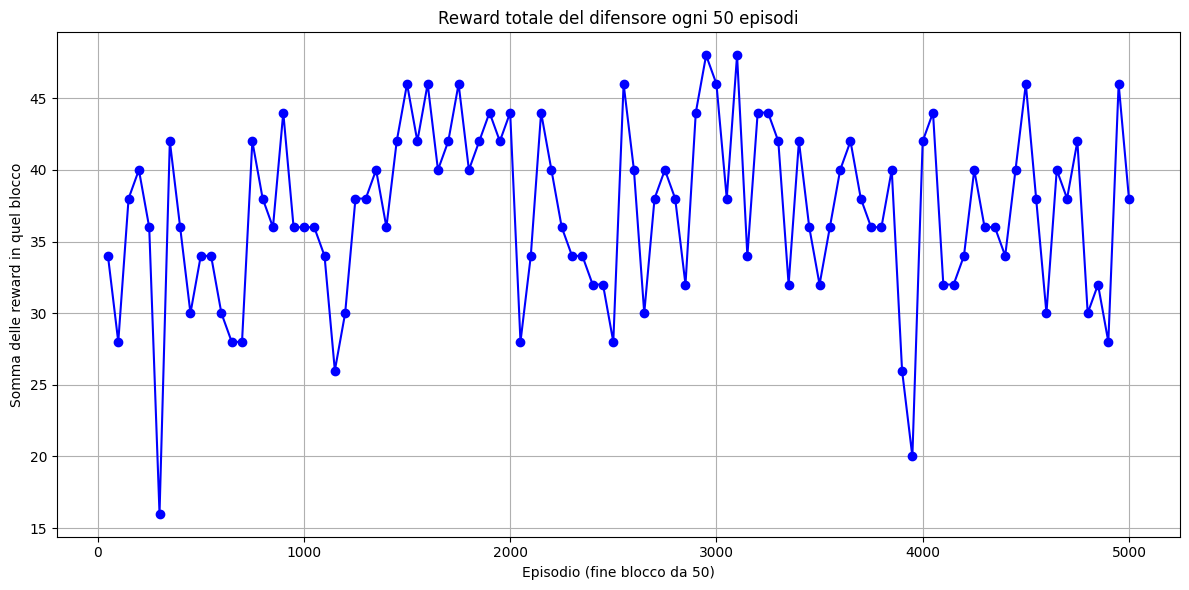

In [21]:
Plotting.plot_50_episode_sums(np.array(randomattack_episode_rewards).flatten())

Notiamo che SARSA tende a fare fatica a raggiungere reward elevate, anche se con più episodi potrebbe raggiungere la convergenza (e più tempo!). Nonostante ciò, si evidenzia una crescita coerente della reward, segno che l'agent sta effettivamente apprendendo le policy opportune.

Effettuiamo ora una valutazione con la Q-Table appresa:

In [39]:
#Evaluation

randomattack_evaluation_episode_rewards, evaluation_total = SARSA.evaluate_sarsa(random_env, Q, verbose=False)

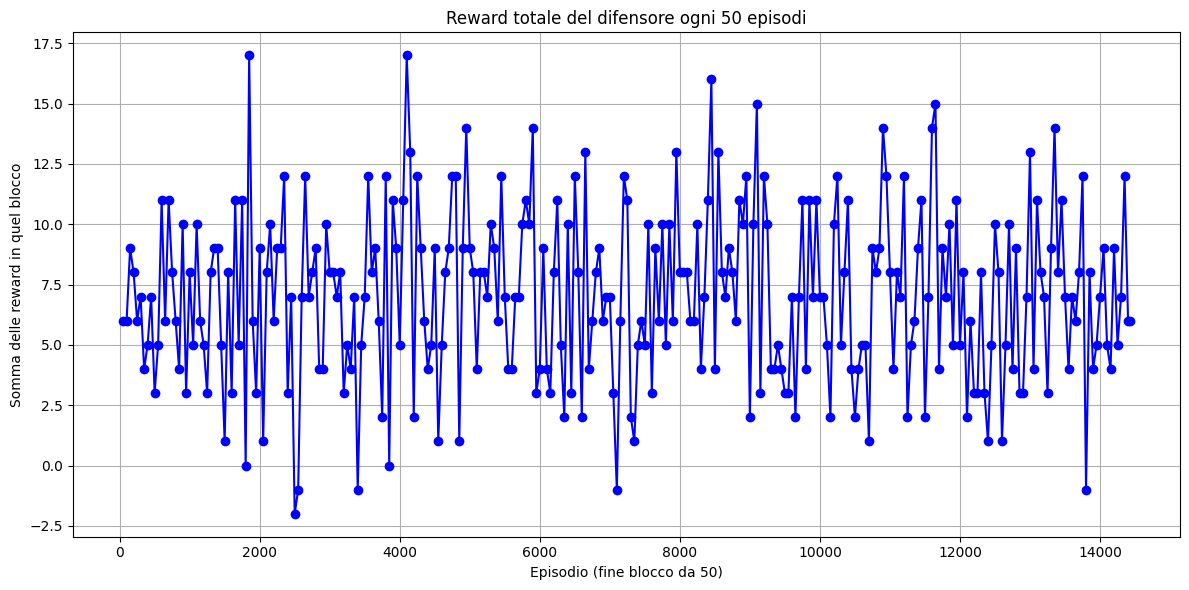

In [43]:
Plotting.plot_50_episode_sums(randomattack_evaluation_episode_rewards)

E notiamo che, pur essendoci differenza rispetto al training, l'agent **Defender** ottiene discrete reward, riuscendo a gestire opportunamente le minacce dell'ambiente.

## Scenario 2 - Random Attack with DDQN

Implementiamo ora l'algoritmo DDQN per eseguire lo stesso scenario, confrontando i risultati con SARSA:

In [65]:
obs = random_env.reset()[0]
state_dim = obs.flatten().shape[0] #observation is represented as a tuple [0: attacker, 1: defender].

defender_action_space = random_env.defender_action_space.n

replaybuffer = ReplayBuffer()

In [22]:
#Neural Networks setup

online_net = DQN(state_dim, defender_action_space)
target_net = DQN(state_dim, defender_action_space)

summary(online_net, (44,))
summary(target_net, (44,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]          23,040
            Linear-2                   [-1, 44]          22,572
Total params: 45,612
Trainable params: 45,612
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.17
Estimated Total Size (MB): 0.18
----------------------------------------------------------------
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]          23,040
            Linear-2                   [-1, 44]          22,572
Total params: 45,612
Trainable params: 45,612
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backwa

Effettuiamo il training, monitorando le rewards per episodio:

In [66]:
randomattack_ddqn_episode_rewards = DDQN.ddqn(random_env, online_net, target_net, replaybuffer)

Episode 1, Total reward: 1
Episode 2, Total reward: 1
Episode 3, Total reward: 1
Episode 4, Total reward: -1
Episode 5, Total reward: 1
Episode 6, Total reward: 1
Episode 7, Total reward: 1
Episode 8, Total reward: -1
Episode 9, Total reward: 1
Episode 10, Total reward: 1
Episode 11, Total reward: 1
Episode 12, Total reward: 1
Episode 13, Total reward: 1
Episode 14, Total reward: 1
Episode 15, Total reward: -1
Episode 16, Total reward: 1
Episode 17, Total reward: 1
Episode 18, Total reward: 1
Episode 19, Total reward: 1
Episode 20, Total reward: 1
Episode 21, Total reward: 1
Episode 22, Total reward: 1
Episode 23, Total reward: 1
Episode 24, Total reward: 1
Episode 25, Total reward: 1
Episode 26, Total reward: 1
Episode 27, Total reward: 1
Episode 28, Total reward: 1
Episode 29, Total reward: 1
Episode 30, Total reward: 1
Episode 31, Total reward: 1
Episode 32, Total reward: 1
Episode 33, Total reward: -1
Episode 34, Total reward: 1
Episode 35, Total reward: 1
Episode 36, Total reward:

Salviamo i risultati ottenuti per riproducibilità:

In [61]:
%cd ..

c:\Repositories\proai\course8-rl\project


In [63]:
torch.save(online_net.state_dict(), "./onlinenet_randomattack_scenario.pt")

In [67]:
# Convert replaybuffer to a list of transitions
replaybuffer_data = list(replaybuffer.memory)

# Convert numpy arrays to lists for JSON serialization
def serialize_transition(transition):
    return [x.tolist() if hasattr(x, 'tolist') else x for x in transition]

replaybuffer_serialized = [serialize_transition(t) for t in replaybuffer_data]

with open("replaybuffer_randomattack.json", "w") as f:
    json.dump(replaybuffer_serialized, f)

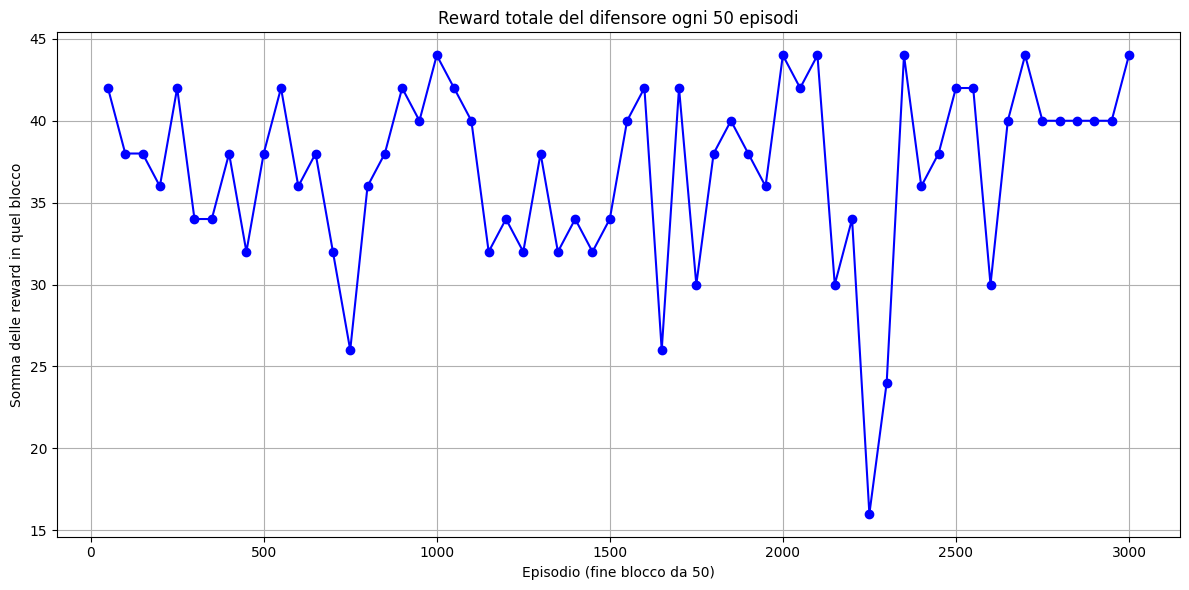

In [25]:
Plotting.plot_50_episode_sums(np.array(randomattack_ddqn_episode_rewards).flatten())

Notiamo che DDQN tende a convergere più rapidamente, nonostante una maggiore instabilità. Probabilmente, con episodi di training più lunghi, l'algoritmo si troverebbe in difficoltà con gli ampi **ReplayBuffer** generati.

Effettuiamo anche qui le nostre valutazioni con la rete con i pesi allenati:

In [49]:
#Evaluation

randomattack_ddqn_eval_episode_rewards, eval_total = DDQN.evaluate_ddqn(random_env, online_net, verbose=False)

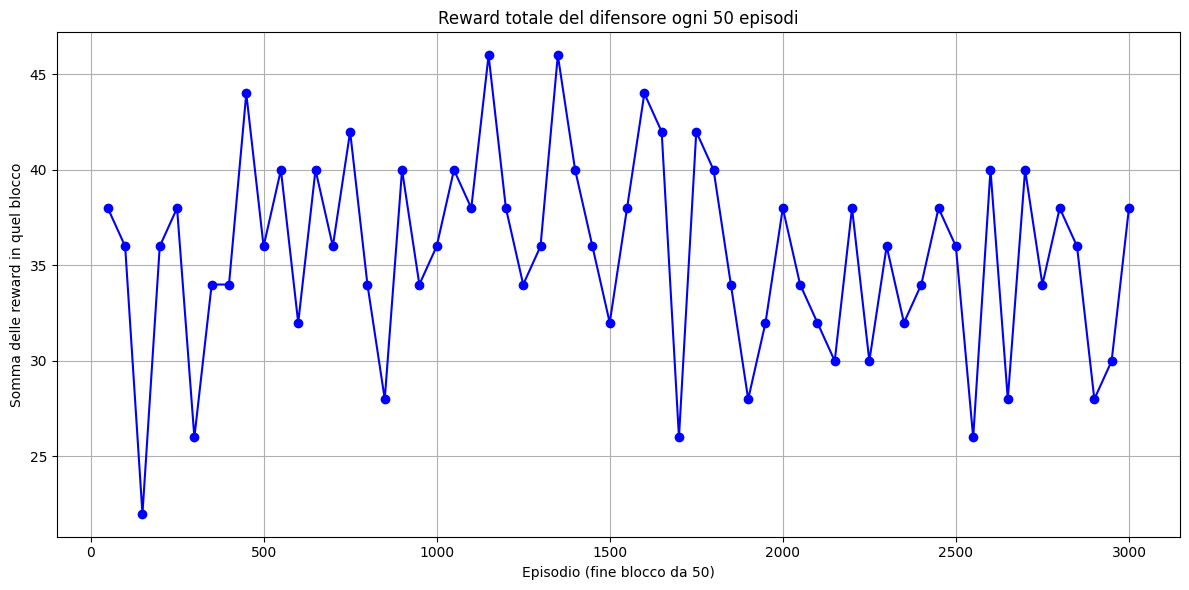

In [50]:
Plotting.plot_50_episode_sums(randomattack_ddqn_eval_episode_rewards)

## Scenario 3 - Maximal Attack with DDQN

In [ ]:
online_net = DQN(state_dim, defender_action_space)
target_net = DQN(state_dim, defender_action_space)

summary(online_net, (44,))
summary(target_net, (44,))

In [26]:
maximal_env.reset()

(array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]),
 {})

In [27]:
maximalattack_ddqn_episode_rewards = DDQN.ddqn(random_env, online_net, target_net, ReplayBuffer())

Episode 1, Total reward: -1
Episode 2, Total reward: 1
Episode 3, Total reward: 1
Episode 4, Total reward: 1
Episode 5, Total reward: 1
Episode 6, Total reward: 1
Episode 7, Total reward: -1
Episode 8, Total reward: 1
Episode 9, Total reward: 1
Episode 10, Total reward: 1
Episode 11, Total reward: 1
Episode 12, Total reward: 1
Episode 13, Total reward: 1
Episode 14, Total reward: 1
Episode 15, Total reward: 1
Episode 16, Total reward: 1
Episode 17, Total reward: 1
Episode 18, Total reward: 1
Episode 19, Total reward: 1
Episode 20, Total reward: -1
Episode 21, Total reward: -1
Episode 22, Total reward: 1
Episode 23, Total reward: -1
Episode 24, Total reward: 1
Episode 25, Total reward: 1
Episode 26, Total reward: -1
Episode 27, Total reward: 1
Episode 28, Total reward: 1
Episode 29, Total reward: 1
Episode 30, Total reward: 1
Episode 31, Total reward: 1
Episode 32, Total reward: 1
Episode 33, Total reward: 1
Episode 34, Total reward: 1
Episode 35, Total reward: 1
Episode 36, Total rewar

In [ ]:
torch.save(online_net.state_dict(), "./onlinenet_maximalattack_scenario.pt")

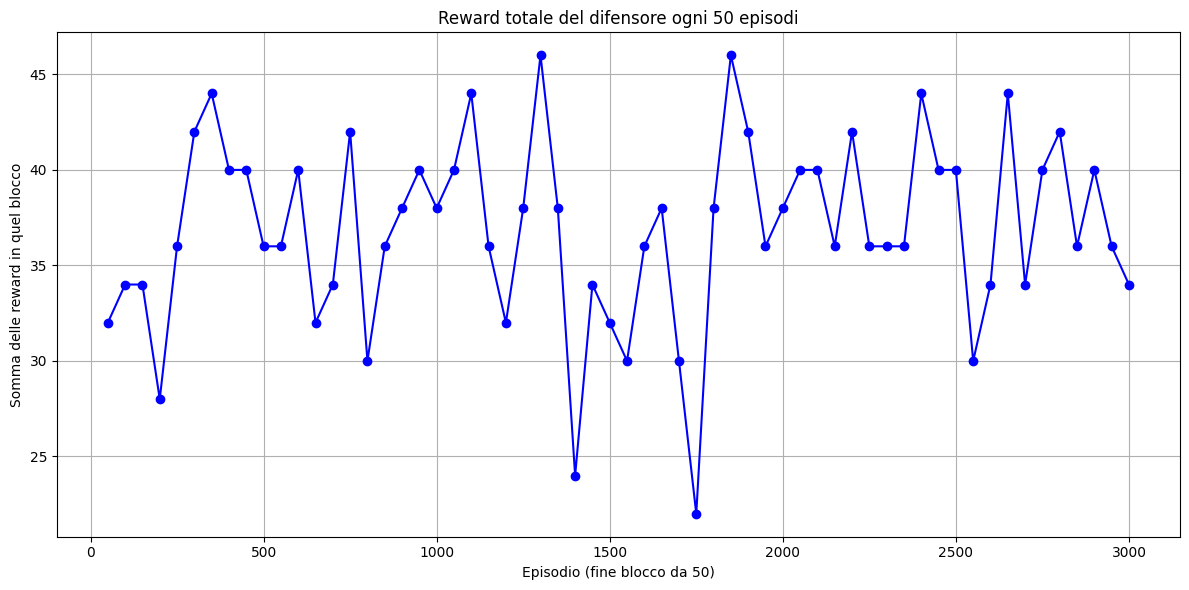

In [28]:
Plotting.plot_50_episode_sums(np.array(maximalattack_ddqn_episode_rewards).flatten())

In [51]:
#Evaluation

maximalattack_ddqn_eval_episode_rewards, eval_total = DDQN.evaluate_ddqn(maximal_env, online_net, verbose=False)

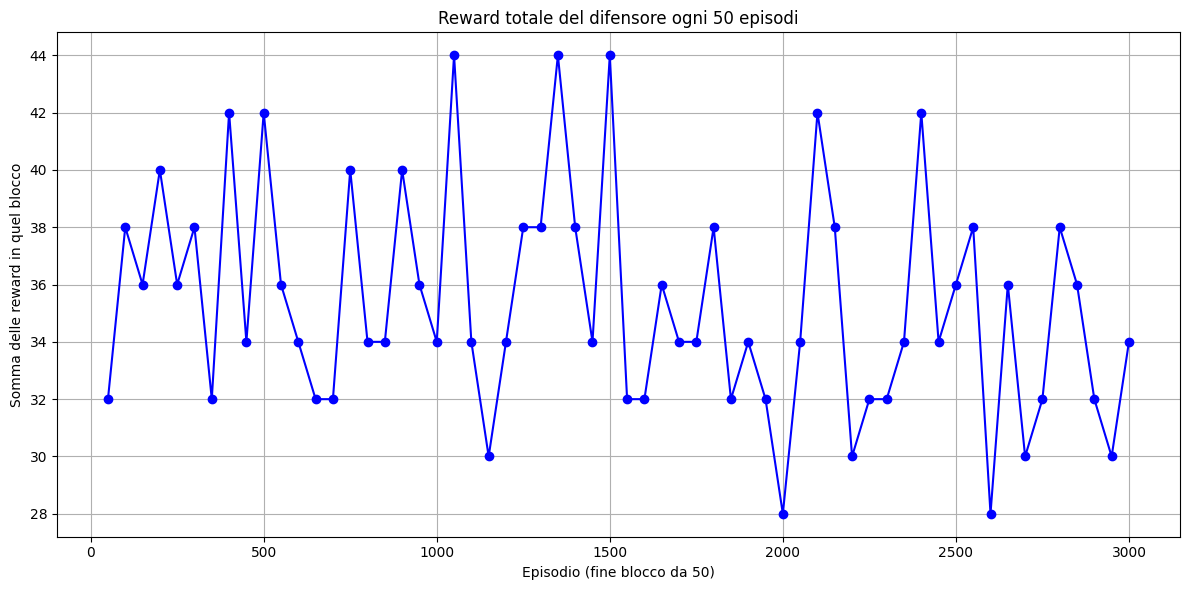

In [52]:
Plotting.plot_50_episode_sums(maximalattack_ddqn_eval_episode_rewards)

## Considerazioni finali e miglioramenti

## Crediti